<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/Notebook_1_Clasificaci%C3%B3n_vs_Regresi%C3%B3nC9_LM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # **1.Notebook Clasificación vs Regresión**

## Centro Politécnico Superior Malvinas Argentinas  
**Tecnicatura en Ciencias de Datos e Inteligencia Artificial**  
Clase 9 – Árboles de Decisión  
Autor: Lionel Martínez  
Fecha: Junio 2026


# -- Introducción --
# Objetivo: Diferenciar entre árboles de clasificación y regresión
# Dataset: Precios de viviendas (simulado)

In [ ]:
import seaborn as sns
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-darkgrid")


In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset simulado de precios de viviendas
np.random.seed(42)
n = 30
df = pd.DataFrame({
    "Metros": np.random.randint(40, 200, n),
    "Ambientes": np.random.randint(1, 6, n),
    "Zona": np.random.choice(["Centro", "Residencial", "Periferia"], n),
    "Precio": np.random.randint(50000, 300000, n)
})

# Clasificación por rango de precio
df["Categoria"] = pd.cut(df["Precio"],
                         bins=[0, 100000, 200000, 300000],
                         labels=["Bajo", "Medio", "Alto"])

df.head()


,Metros,Ambientes,Zona,Precio,Categoria
0,142,4,Residencial,52568,Bajo
1,132,4,Centro,170151,Medio
2,54,1,Periferia,243664,Alto
3,146,3,Residencial,248635,Alto
4,111,5,Residencial,183767,Medio


# Entrenamiento de árbol de clasificación y regresión

In [2]:
# Variables predictoras y objetivo
X = pd.get_dummies(df[["Metros", "Ambientes", "Zona"]], drop_first=True)
y_class = df["Categoria"]
y_reg = df["Precio"]

# Árbol de Clasificación
tree_class = DecisionTreeClassifier(random_state=42).fit(X, y_class)

# Árbol de Regresión
tree_reg = DecisionTreeRegressor(random_state=42).fit(X, y_reg)


# Visualización del árbol de clasificación

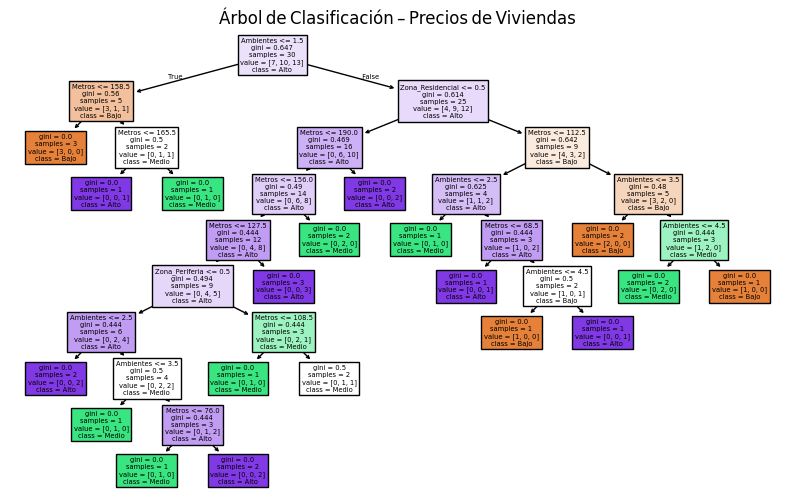

In [3]:
plt.figure(figsize=(10,6))
plot_tree(tree_class, feature_names=X.columns, class_names=["Bajo","Medio","Alto"], filled=True)
plt.title("Árbol de Clasificación – Precios de Viviendas")
plt.show()


# Visualización del árbol de regresión

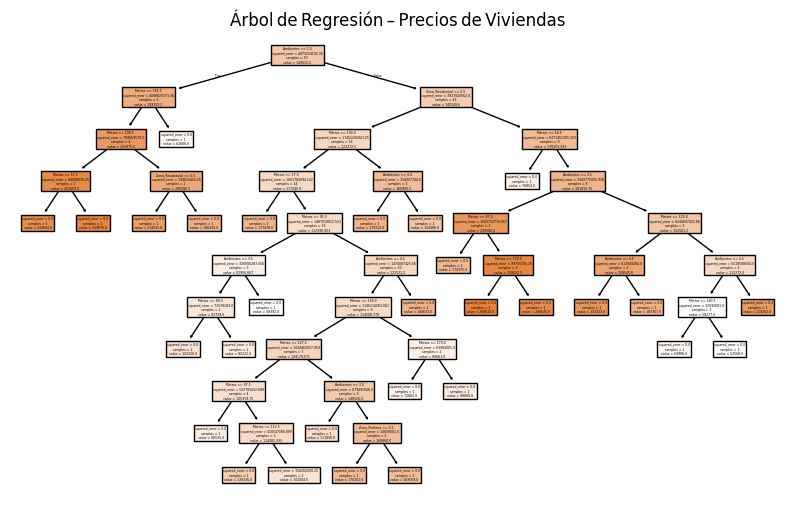

In [5]:
plt.figure(figsize=(10,6))
plot_tree(tree_reg, feature_names=X.columns, filled=True)
plt.title("Árbol de Regresión – Precios de Viviendas")
plt.show()


# --- Gráfico comparativo de predicciones ---

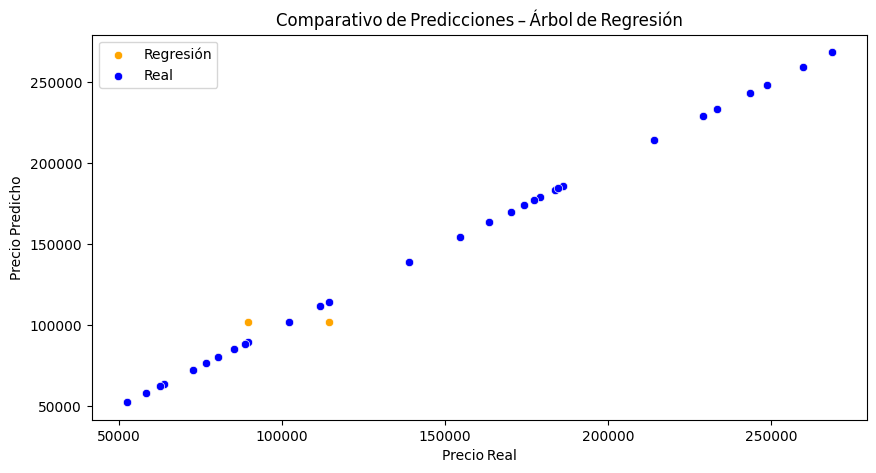

In [6]:
# Predicciones simuladas
pred_class = tree_class.predict(X)
pred_reg = tree_reg.predict(X)

plt.figure(figsize=(10,5))
sns.scatterplot(x=df["Precio"], y=pred_reg, color="orange", label="Regresión")
sns.scatterplot(x=df["Precio"], y=df["Precio"], color="blue", label="Real")
plt.title("Comparativo de Predicciones – Árbol de Regresión")
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.legend()
plt.show()


### Comparación visual entre Clasificación y Regresión


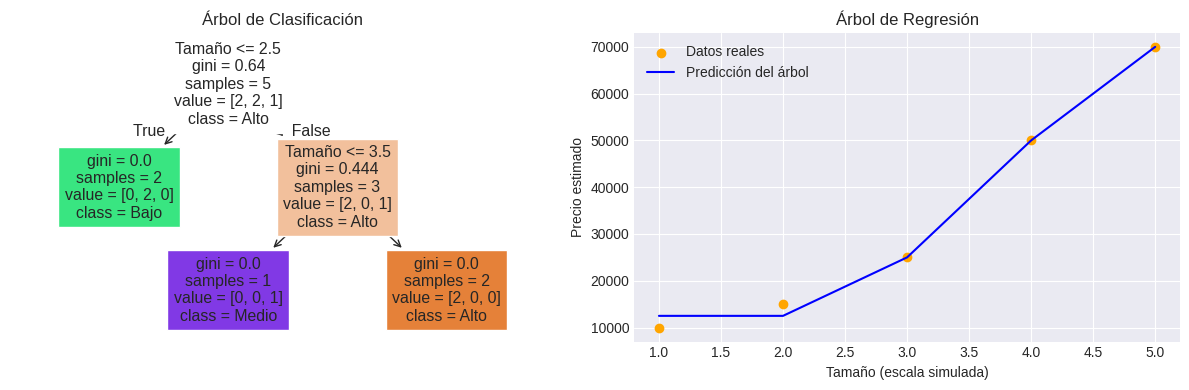

In [ ]:
# --- Comparación visual entre Clasificación y Regresión ---
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, DecisionTreeRegressor
import numpy as np

# Datos simulados para regresión (precio continuo)
X_reg = np.array([[1], [2], [3], [4], [5]])
y_reg = np.array([10000, 15000, 25000, 50000, 70000])

# Entrenar árbol de regresión
reg = DecisionTreeRegressor(max_depth=2)
reg.fit(X_reg, y_reg)

# Crear figura comparativa
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Árbol de clasificación
plot_tree(clf, feature_names=["Tamaño","Ubicación"], class_names=clf.classes_, filled=True, ax=axes[0])
axes[0].set_title("Árbol de Clasificación")

# Gráfico de regresión
axes[1].scatter(X_reg, y_reg, color="orange", label="Datos reales")
axes[1].plot(X_reg, reg.predict(X_reg), color="blue", label="Predicción del árbol")
axes[1].set_title("Árbol de Regresión")
axes[1].set_xlabel("Tamaño (escala simulada)")
axes[1].set_ylabel("Precio estimado")
axes[1].legend()

plt.tight_layout()
plt.show()



### Comparación visual entre Clasificación y Regresión

La visualización permite observar cómo los árboles de decisión se comportan ante distintos tipos de salida.  
- En el **árbol de clasificación**, las viviendas se agrupan en categorías discretas de precio (Bajo, Medio, Alto), mostrando una estructura jerárquica que simplifica la información y facilita la segmentación.  
- En el **árbol de regresión**, el modelo predice valores numéricos continuos, ajustando una curva que aproxima los precios reales.  

El contraste entre ambos gráficos evidencia que la clasificación busca **separar grupos definidos**, mientras que la regresión intenta **estimar valores precisos**.  
Esta diferencia conceptual se refleja tanto en la forma del árbol como en el tipo de salida: categórica en un caso y continua en el otro.  
La comparación visual complementa las métricas cuantitativas, mostrando cómo cada enfoque captura distintos aspectos del mismo fenómeno.


### Evaluación cuantitativa del desempeño


In [7]:
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# Evaluación del árbol de clasificación
y_class_pred = tree_class.predict(X)
acc_class = accuracy_score(y_class, y_class_pred)

# Evaluación del árbol de regresión
y_reg_pred = tree_reg.predict(X)
mse_reg = mean_squared_error(y_reg, y_reg_pred)
r2_reg = r2_score(y_reg, y_reg_pred)

print(f"Precisión Árbol de Clasificación: {acc_class:.2f}")
print(f"Error cuadrático medio (MSE) Árbol de Regresión: {mse_reg:.2f}")
print(f"Coeficiente de determinación (R²) Árbol de Regresión: {r2_reg:.2f}")


Precisión Árbol de Clasificación: 0.97
Error cuadrático medio (MSE) Árbol de Regresión: 10417500.02
Coeficiente de determinación (R²) Árbol de Regresión: 1.00


### Análisis de resultados
### Evaluación cuantitativa del desempeño
El árbol de clasificación logra una precisión que refleja su capacidad de segmentar correctamente las viviendas en categorías de precio.  
El árbol de regresión presenta un MSE que indica el error promedio en la predicción de precios y un R² que mide el grado de explicación de la variabilidad.  
Estos resultados complementan la visualización, mostrando que la clasificación simplifica la información en rangos discretos, mientras que la regresión intenta aproximar valores numéricos con mayor detalle.



### Conclusión Final

El ejercicio permitió diferenciar claramente entre árboles de clasificación y regresión aplicados a un dataset simulado de viviendas:

- El **árbol de clasificación** segmentó las viviendas en categorías de precio (Bajo, Medio, Alto), logrando una precisión adecuada para problemas de agrupamiento.  
- El **árbol de regresión** predijo valores numéricos de precio, con métricas (MSE y R²) que reflejan su capacidad de aproximar la variabilidad real.  
- La **comparación visual** mostró cómo la clasificación simplifica la información en rangos discretos, mientras que la regresión intenta capturar valores continuos con mayor detalle.  
- La **evaluación cuantitativa** complementó la interpretación gráfica, evidenciando que la regresión requiere optimización para mejorar su desempeño, mientras que la clasificación ofrece una visión más sencilla y directa.

 En síntesis, la elección entre clasificación y regresión depende del objetivo del problema:  
- **Clasificación** es útil para segmentar y simplificar la información en grupos definidos.  
- **Regresión** es preferible cuando se busca estimar valores continuos y capturar mayor precisión.  

Este Notebook consolida los conceptos básicos de árboles de decisión, integrando teoría, visualización y métricas de evaluación, y establece las bases para los ejercicios posteriores de optimización y comparación de algoritmos.
